In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


In [14]:
import os

os.listdir('.')


['.idea',
 '.venv',
 '2019-Nov.csv',
 '2019-Oct.csv',
 'data',
 'models',
 'README.md',
 'requirements.txt',
 'sample.ipynb']

In [24]:
df_oct = pd.read_csv('2019-Oct.csv', nrows=500000)

df_nov = pd.read_csv('2019-Nov.csv', nrows=500000)

df = pd.concat([df_oct, df_nov], ignore_index=True)


In [25]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.96,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.16,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.71,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [26]:
df.info()

<bound method DataFrame.info of                      event_time event_type  product_id          category_id  \
0       2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1       2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2       2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3       2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4       2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   
...                         ...        ...         ...                  ...   
999995  2019-11-01 09:18:16 UTC       view    21408811  2053013561579406073   
999996  2019-11-01 09:18:16 UTC       view    26300509  2053013563424899933   
999997  2019-11-01 09:18:17 UTC       view    10800074  2053013554994348409   
999998  2019-11-01 09:18:17 UTC       view     1005116  2053013555631882655   
999999  2019-11-01 09:18:17 UTC       view     1801623  2053013554415534427   

                   

In [27]:
print(df.columns.tolist())

['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [28]:
missing_values = df.isnull().sum()
print(missing_values)

event_time            0
event_type            0
product_id            0
category_id           0
category_code    320811
brand            146642
price                 0
user_id               0
user_session          0
dtype: int64


In [29]:
df = df.drop_duplicates()


In [30]:
df.isnull()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
999995,False,False,False,False,False,False,False,False,False
999996,False,False,False,False,True,True,False,False,False
999997,False,False,False,False,True,False,False,False,False
999998,False,False,False,False,False,False,False,False,False


In [31]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    320703
brand            146627
price                 0
user_id               0
user_session          0
dtype: int64

In [42]:
pd.to_datetime(df['event_time'], errors='coerce')

0        2019-10-01 00:00:00+00:00
1        2019-10-01 00:00:00+00:00
2        2019-10-01 00:00:01+00:00
3        2019-10-01 00:00:01+00:00
4        2019-10-01 00:00:04+00:00
                    ...           
999995   2019-11-01 09:18:16+00:00
999996   2019-11-01 09:18:16+00:00
999997   2019-11-01 09:18:17+00:00
999998   2019-11-01 09:18:17+00:00
999999   2019-11-01 09:18:17+00:00
Name: event_time, Length: 999477, dtype: datetime64[us, UTC]

In [43]:
df.drop_duplicates(subset=None, keep='first', inplace=True)

In [46]:
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

print(df.isnull().sum())

event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     0
dtype: int64


In [47]:
df['price'] = df['price'].fillna(df['price'].median())

In [48]:
df['event_time'] = pd.to_datetime(
    df['event_time'],
    errors='coerce'
)

print(df['event_time'].dtype)

datetime64[us, UTC]


In [49]:
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

In [50]:
print("Дубликатов:", df.duplicated().sum())

df = df.drop_duplicates()

In [51]:
print(df['price'].describe())

count    999477.000000
mean        291.411901
std         357.031082
min           0.000000
25%          64.610000
50%         162.170000
75%         360.260000
max        2574.070000
Name: price, dtype: float64


In [53]:
df = df[df['price'] >= 0]

In [54]:
print(df['event_type'].value_counts())

event_type
view        964407
purchase     19352
cart         15718
Name: count, dtype: int64


In [55]:
valid_events = ['view', 'cart', 'purchase']

df = df[df['event_type'].isin(valid_events)]

In [56]:
df = pd.get_dummies(
    df,
    columns=['event_type'],
    prefix='event',
    dtype=int
)

In [57]:
df = df.sort_values(['user_session', 'event_time'])

In [58]:
session_time = (
    df.groupby('user_session')['event_time']
      .agg(['min', 'max'])
)

session_time['session_duration_min'] = (
    session_time['max'] - session_time['min']
).dt.total_seconds() / 60

In [59]:
print(session_time['session_duration_min'].describe())

count    239236.000000
mean          4.922417
std         130.668018
min           0.000000
25%           0.000000
50%           0.950000
75%           3.966667
max       45002.400000
Name: session_duration_min, dtype: float64


In [60]:
category_time = (
    df.groupby('category_code')['user_session']
      .nunique()
      .sort_values(ascending=False)
)

print(category_time.head(10))

category_code
unknown                             86081
electronics.smartphone              78624
electronics.audio.headphone          9816
electronics.clocks                   9418
electronics.video.tv                 6580
computers.notebook                   6465
appliances.kitchen.refrigerators     5069
appliances.kitchen.washer            4789
appliances.environment.vacuum        4725
apparel.shoes                        4437
Name: user_session, dtype: int64


In [61]:
category_time = (
    df.groupby('category_code')['user_session']
      .nunique()
      .sort_values(ascending=False)
)

print(category_time.head(10))

category_code
unknown                             86081
electronics.smartphone              78624
electronics.audio.headphone          9816
electronics.clocks                   9418
electronics.video.tv                 6580
computers.notebook                   6465
appliances.kitchen.refrigerators     5069
appliances.kitchen.washer            4789
appliances.environment.vacuum        4725
apparel.shoes                        4437
Name: user_session, dtype: int64


In [62]:
daily_activity = (
    df.groupby(df['event_time'].dt.date)
      .size()
      .reset_index(name='events')
)

daily_activity['growth_rate'] = (
    daily_activity['events'].pct_change() * 100
)

daily_activity.head()

,event_time,events,growth_rate
0,2019-10-01,499712,NaN
1,2019-11-01,499765,0.010606


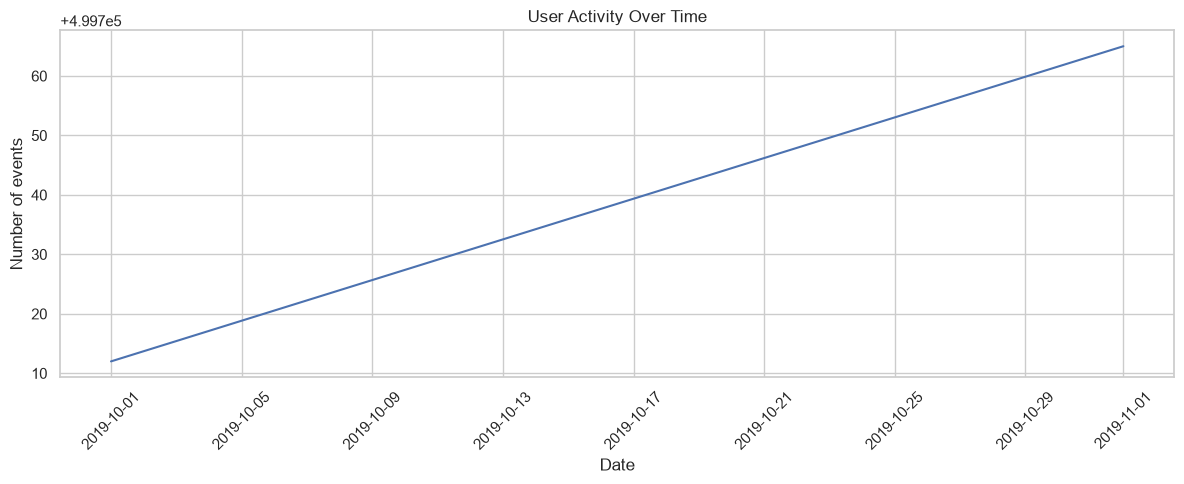

In [65]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_activity['event_time'],
    daily_activity['events']
)

plt.xlabel('Date')
plt.ylabel('Number of events')
plt.title('User Activity Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

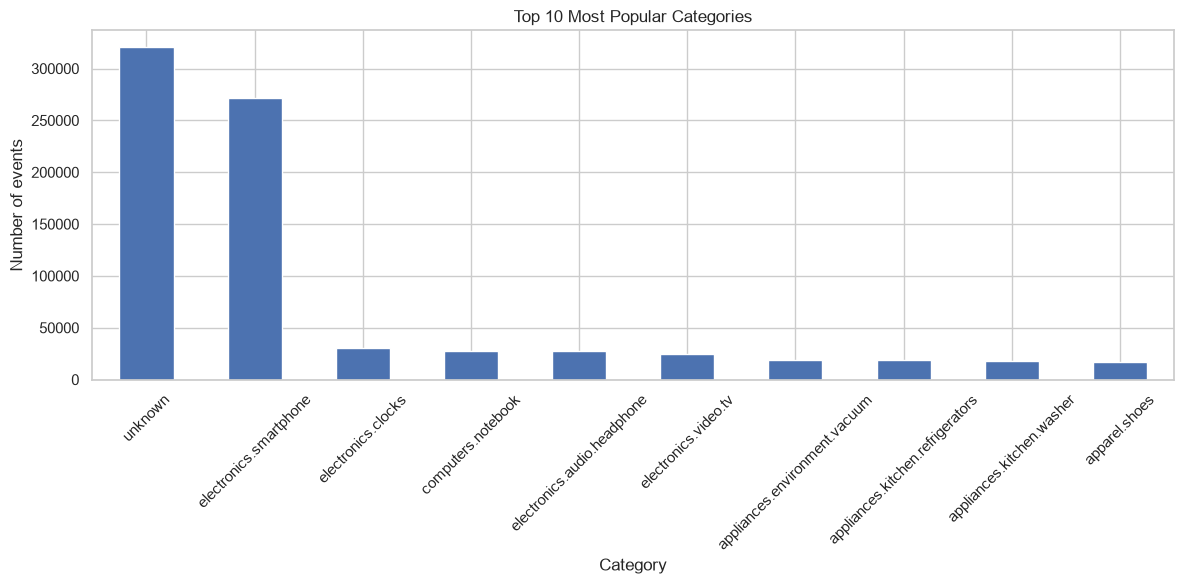

In [66]:
top_categories = (
    df['category_code']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

top_categories.plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Number of events')
plt.title('Top 10 Most Popular Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

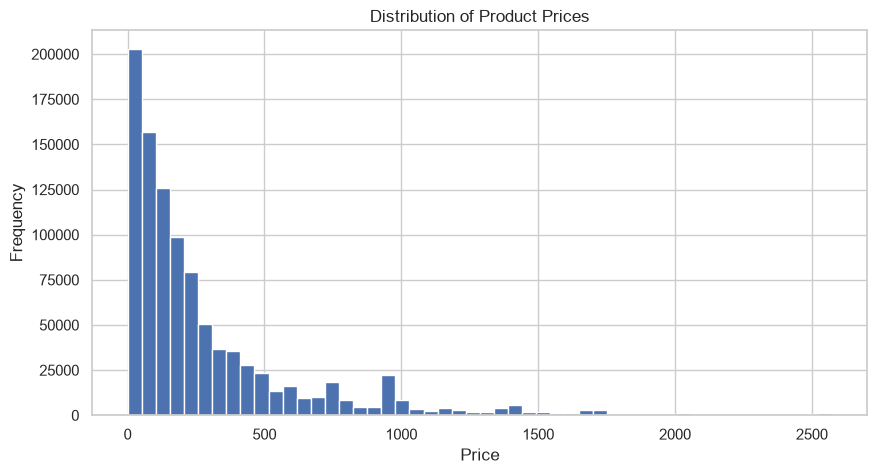

In [67]:
plt.figure(figsize=(10, 5))

plt.hist(df['price'], bins=50)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Product Prices')

plt.show()

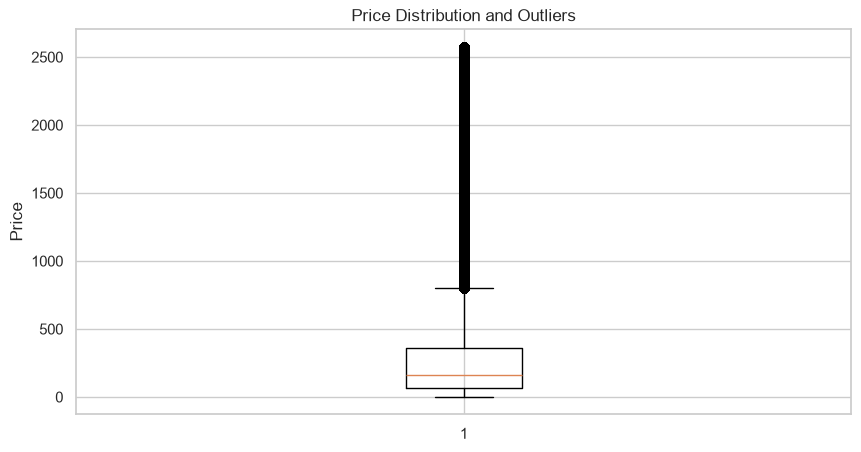

In [68]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['price'].dropna())

plt.ylabel('Price')
plt.title('Price Distribution and Outliers')

plt.show()